In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("Figure", exist_ok=True)

# ---------- Figure / font style ----------

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

# ---------- Use LaTeX ----------
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]
plt.rcParams["axes.unicode_minus"] = False


In [2]:
# 改成你的实际文件名；如果你重跑时还是原来的 output_name，这里通常不用改
CASE1_FILE = "data/case1_powerlaw_scan.npz"
CASE2_FILE = "data/case2_truncated_scan.npz"

case1 = np.load(CASE1_FILE, allow_pickle=True)
case2 = np.load(CASE2_FILE, allow_pickle=True)

# Case I
case1_t = np.array(case1["t_points"], dtype=float)
case1_local = case1["local_data"]
case1_nonlocal = case1["nonlocal_data"]
case1_alphas = np.array(case1["alpha_values"], dtype=float)
case1_etas = np.array(case1["eta_values"], dtype=float)

# Case II
case2_t = np.array(case2["t_points"], dtype=float)
case2_local = case2["local_data"]
case2_trunc = case2["truncated_data"]
case2_alphas = np.array(case2["alpha_values"], dtype=float)
case2_betas = np.array(case2["beta_values"], dtype=float)

print("Case I alphas:", case1_alphas)
print("Case I etas:", case1_etas)
print("Case II alphas:", case2_alphas)
print("Case II betas:", case2_betas)

def _to_dict(item):
    return item.item() if hasattr(item, "item") else item

print("Case I sample keys:", _to_dict(case1_nonlocal[0]).keys())
print("Case II sample keys:", _to_dict(case2_trunc[0]).keys())

Case I alphas: [0.5 1.5 2.5 3.5]
Case I etas: [0.2 0.5 0.8 1.2 1.6 2. ]
Case II alphas: [0.5 1.5 2.5 3.5]
Case II betas: [0.  0.2 0.4 0.6 0.8 1. ]
Case I sample keys: dict_keys(['N', 'alpha', 'eta', 'qfi', 'qfi_groups'])
Case II sample keys: dict_keys(['N', 'alpha', 'beta', 'R0', 'qfi', 'qfi_groups'])


In [3]:
def to_dict_list(arr):
    out = []
    for x in arr:
        out.append(_to_dict(x))
    return out


# =========================
# basic smoothing / auto optimum
# =========================
def moving_average(x, w=5):
    x = np.asarray(x, dtype=float)
    if w <= 1 or len(x) < 3:
        return x.copy()

    w = int(w)
    w = max(1, min(w, len(x)))
    pad = w // 2
    x_pad = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(w, dtype=float) / w
    y = np.convolve(x_pad, kernel, mode="valid")
    return y[:len(x)]


def find_optimal_index_auto(
    qfi,
    t_list,
    smooth_window=5,
    rise_steps=3,
    min_rebound_ratio=1.02,
):
    """
    自动找 Delta_opt 对应的 interior optimum:
    1) 看 y=qfi/t
    2) 轻微平滑
    3) 找第一次“先经历下降，然后连续 rise_steps 步上升”的位置
    4) 从那里往后取最大值
    """
    qfi = np.asarray(qfi, dtype=float)
    t_list = np.asarray(t_list, dtype=float)

    mask = t_list > 0
    if np.sum(mask) < max(8, smooth_window + rise_steps + 2):
        return None

    idx_map = np.where(mask)[0]
    t = t_list[mask]
    y = qfi[mask] / t

    if np.any(~np.isfinite(y)):
        return None

    y_s = moving_average(y, w=smooth_window)
    dy = np.diff(y_s)

    seen_drop = False
    start = None
    for i in range(len(dy) - rise_steps + 1):
        if dy[i] < 0:
            seen_drop = True
        if seen_drop and np.all(dy[i:i + rise_steps] > 0):
            start = i + 1
            break

    if start is None:
        return None
    if start >= len(y_s) - 1:
        return None

    j = start + int(np.argmax(y_s[start:]))

    # 峰如果落在最后一个点，通常说明当前时间窗内还没形成可靠 interior optimum
    if j >= len(y_s) - 1:
        return None

    # 谷后回升太弱，也不认为是可靠 interior optimum
    if y_s[j] < min_rebound_ratio * y_s[start]:
        return None

    return int(idx_map[j])


def best_value_from_curve(
    qfi,
    t_list,
    smooth_window=5,
    rise_steps=3,
    min_rebound_ratio=1.10,
):
    idx = find_optimal_index_auto(
        qfi,
        t_list,
        smooth_window=smooth_window,
        rise_steps=rise_steps,
        min_rebound_ratio=min_rebound_ratio,
    )
    if idx is None:
        return None, np.nan
    return idx, float(qfi[idx] / t_list[idx])


# =========================
# data access
# =========================
def get_case1_local_curve(alpha, N):
    for raw in case1_local:
        item = _to_dict(raw)
        if np.isclose(item["alpha"], alpha) and int(item["N"]) == int(N):
            return np.array(item["qfi"], dtype=float)
    raise ValueError(f"Case I local data not found for alpha={alpha}, N={N}")


def get_case1_nonlocal_entry(alpha, eta, N):
    for raw in case1_nonlocal:
        item = _to_dict(raw)
        if (
            np.isclose(item["alpha"], alpha)
            and np.isclose(item["eta"], eta)
            and int(item["N"]) == int(N)
        ):
            return item
    raise ValueError(f"Case I nonlocal data not found for alpha={alpha}, eta={eta}, N={N}")


def get_case1_nonlocal_curve(alpha, eta, N):
    item = get_case1_nonlocal_entry(alpha, eta, N)
    return np.array(item["qfi"], dtype=float)


def get_case1_nonlocal_groups(alpha, eta, N):
    item = get_case1_nonlocal_entry(alpha, eta, N)
    return np.array(item["qfi_groups"], dtype=float)


def get_case2_local_curve(alpha, N):
    for raw in case2_local:
        item = _to_dict(raw)
        if np.isclose(item["alpha"], alpha) and int(item["N"]) == int(N):
            return np.array(item["qfi"], dtype=float)
    raise ValueError(f"Case II local data not found for alpha={alpha}, N={N}")


def get_case2_truncated_entry(alpha, beta, N):
    for raw in case2_trunc:
        item = _to_dict(raw)
        if (
            np.isclose(item["alpha"], alpha)
            and np.isclose(item["beta"], beta)
            and int(item["N"]) == int(N)
        ):
            return item
    raise ValueError(f"Case II truncated data not found for alpha={alpha}, beta={beta}, N={N}")


def get_case2_truncated_curve(alpha, beta, N):
    item = get_case2_truncated_entry(alpha, beta, N)
    return np.array(item["qfi"], dtype=float), int(item["R0"])


def get_case2_truncated_groups(alpha, beta, N):
    item = get_case2_truncated_entry(alpha, beta, N)
    return np.array(item["qfi_groups"], dtype=float), int(item["R0"])


# =========================
# available N
# =========================
def available_N_case1_local(alpha):
    Ns = []
    for raw in case1_local:
        item = _to_dict(raw)
        if np.isclose(item["alpha"], alpha):
            Ns.append(int(item["N"]))
    return sorted(set(Ns))


def available_N_case1_nonlocal(alpha, eta):
    Ns = []
    for raw in case1_nonlocal:
        item = _to_dict(raw)
        if np.isclose(item["alpha"], alpha) and np.isclose(item["eta"], eta):
            Ns.append(int(item["N"]))
    return sorted(set(Ns))


def available_N_case2_local(alpha):
    Ns = []
    for raw in case2_local:
        item = _to_dict(raw)
        if np.isclose(item["alpha"], alpha):
            Ns.append(int(item["N"]))
    return sorted(set(Ns))


def available_N_case2_truncated(alpha, beta):
    Ns = []
    for raw in case2_trunc:
        item = _to_dict(raw)
        if np.isclose(item["alpha"], alpha) and np.isclose(item["beta"], beta):
            Ns.append(int(item["N"]))
    return sorted(set(Ns))


# =========================
# fit Delta
# =========================
def fit_delta_from_best_values(N_values, best_qfi_over_t):
    N_values = np.asarray(N_values, dtype=float)
    best_qfi_over_t = np.asarray(best_qfi_over_t, dtype=float)

    mask = np.isfinite(best_qfi_over_t) & (best_qfi_over_t > 0)
    if np.sum(mask) < 3:
        return np.nan, np.nan, np.nan

    x = np.log(N_values[mask])
    y = np.log(best_qfi_over_t[mask])
    slope, intercept = np.polyfit(x, y, 1)
    delta = slope - 1.0
    return float(delta), float(slope), float(intercept)


# =========================
# bootstrap helpers
# =========================
def bootstrap_curve_ci(qfi_groups, n_boot=2000, ci=95, seed=12345):
    qfi_groups = np.asarray(qfi_groups, dtype=float)
    n_groups, n_t = qfi_groups.shape
    rng = np.random.default_rng(seed)

    boots = np.empty((n_boot, n_t), dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n_groups, size=n_groups)
        boots[b] = qfi_groups[idx].mean(axis=0)

    low = np.percentile(boots, (100 - ci) / 2, axis=0)
    high = np.percentile(boots, 100 - (100 - ci) / 2, axis=0)
    return low, high


def bootstrap_best_value_ci(
    qfi_groups,
    t_list,
    n_boot=2000,
    ci=95,
    seed=12345,
    smooth_window=5,
    rise_steps=3,
    min_rebound_ratio=1.10,
):
    qfi_groups = np.asarray(qfi_groups, dtype=float)
    n_groups = qfi_groups.shape[0]
    rng = np.random.default_rng(seed)

    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n_groups, size=n_groups)
        qfi_boot = qfi_groups[idx].mean(axis=0)
        _, best = best_value_from_curve(
            qfi_boot,
            t_list,
            smooth_window=smooth_window,
            rise_steps=rise_steps,
            min_rebound_ratio=min_rebound_ratio,
        )
        if np.isfinite(best):
            vals.append(best)

    vals = np.array(vals, dtype=float)
    if len(vals) == 0:
        return np.nan, np.nan, np.nan

    mean = float(np.mean(vals))
    low = float(np.percentile(vals, (100 - ci) / 2))
    high = float(np.percentile(vals, 100 - (100 - ci) / 2))
    return mean, low, high


def bootstrap_delta_case1(
    alpha,
    eta,
    n_boot=2000,
    ci=95,
    seed=12345,
    smooth_window=5,
    rise_steps=3,
    min_rebound_ratio=1.10,
):
    Ns = available_N_case1_nonlocal(alpha, eta)

    # central value
    Ns_central = []
    best_full = []
    for N in Ns:
        qfi = get_case1_nonlocal_curve(alpha, eta, N)
        _, best = best_value_from_curve(
            qfi,
            case1_t,
            smooth_window=smooth_window,
            rise_steps=rise_steps,
            min_rebound_ratio=min_rebound_ratio,
        )
        if np.isfinite(best):
            Ns_central.append(N)
            best_full.append(best)

    delta_central, _, _ = fit_delta_from_best_values(Ns_central, best_full)

    # bootstrap
    group_dict = {N: get_case1_nonlocal_groups(alpha, eta, N) for N in Ns}
    rng = np.random.default_rng(seed)
    deltas = []

    for _ in range(n_boot):
        Ns_used = []
        best_vals = []

        for N in Ns:
            groups = group_dict[N]
            n_groups = groups.shape[0]
            idx = rng.integers(0, n_groups, size=n_groups)
            qfi_boot = groups[idx].mean(axis=0)

            _, best = best_value_from_curve(
                qfi_boot,
                case1_t,
                smooth_window=smooth_window,
                rise_steps=rise_steps,
                min_rebound_ratio=min_rebound_ratio,
            )
            if np.isfinite(best):
                Ns_used.append(N)
                best_vals.append(best)

        delta_boot, _, _ = fit_delta_from_best_values(Ns_used, best_vals)
        if np.isfinite(delta_boot):
            deltas.append(delta_boot)

    deltas = np.array(deltas, dtype=float)
    if len(deltas) == 0:
        return delta_central, np.nan, np.nan

    low = float(np.percentile(deltas, (100 - ci) / 2))
    high = float(np.percentile(deltas, 100 - (100 - ci) / 2))
    return delta_central, low, high


def bootstrap_delta_case2(
    alpha,
    beta,
    n_boot=2000,
    ci=95,
    seed=12345,
    smooth_window=5,
    rise_steps=3,
    min_rebound_ratio=1.10,
):
    Ns = available_N_case2_truncated(alpha, beta)

    # central value
    Ns_central = []
    best_full = []
    for N in Ns:
        qfi, _ = get_case2_truncated_curve(alpha, beta, N)
        _, best = best_value_from_curve(
            qfi,
            case2_t,
            smooth_window=smooth_window,
            rise_steps=rise_steps,
            min_rebound_ratio=min_rebound_ratio,
        )
        if np.isfinite(best):
            Ns_central.append(N)
            best_full.append(best)

    delta_central, _, _ = fit_delta_from_best_values(Ns_central, best_full)

    # bootstrap
    group_dict = {N: get_case2_truncated_groups(alpha, beta, N)[0] for N in Ns}
    rng = np.random.default_rng(seed)
    deltas = []

    for _ in range(n_boot):
        Ns_used = []
        best_vals = []

        for N in Ns:
            groups = group_dict[N]
            n_groups = groups.shape[0]
            idx = rng.integers(0, n_groups, size=n_groups)
            qfi_boot = groups[idx].mean(axis=0)

            _, best = best_value_from_curve(
                qfi_boot,
                case2_t,
                smooth_window=smooth_window,
                rise_steps=rise_steps,
                min_rebound_ratio=min_rebound_ratio,
            )
            if np.isfinite(best):
                Ns_used.append(N)
                best_vals.append(best)

        delta_boot, _, _ = fit_delta_from_best_values(Ns_used, best_vals)
        if np.isfinite(delta_boot):
            deltas.append(delta_boot)

    deltas = np.array(deltas, dtype=float)
    if len(deltas) == 0:
        return delta_central, np.nan, np.nan

    low = float(np.percentile(deltas, (100 - ci) / 2))
    high = float(np.percentile(deltas, 100 - (100 - ci) / 2))
    return delta_central, low, high

In [4]:
# ---------- Main plotting choices ----------

# 自动 interior optimum 识别参数（全局统一，不再手调 cut）
AUTO_SMOOTH_WINDOW = 5
AUTO_RISE_STEPS = 3
AUTO_MIN_REBOUND_RATIO = 1.10

# bootstrap 参数
BOOT_N = 2000
BOOT_CI = 95
BOOT_SEED = 12345

# Fig. 1: Case I, alpha < 1
alpha_case1_main = 0.5
N_case1_main = 80
etas_case1_time = [0.2, 0.5, 0.8, 1.2, 1.6, 2.0]
etas_case1_delta = [0.2, 0.5, 0.8, 1.2, 1.6, 2.0]

# Fig. 2: Case II, alpha < 1
alpha_case2_main = 0.5
N_case2_main = 80
betas_case2_time = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
betas_case2_delta = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Fig. 3: alpha > 1 representative advantage
alpha_gt1_case1 = 1.5
alpha_gt1_case2 = 1.5
N_gt1 = 80
etas_case1_gt1 = [0.2, 0.8, 1.6]
betas_case2_gt1 = [0.0, 0.6, 1.0]


def pick_idx(qfi, t_list):
    return find_optimal_index_auto(
        qfi,
        t_list,
        smooth_window=AUTO_SMOOTH_WINDOW,
        rise_steps=AUTO_RISE_STEPS,
        min_rebound_ratio=AUTO_MIN_REBOUND_RATIO,
    )


def best_from_curve(qfi, t_list):
    return best_value_from_curve(
        qfi,
        t_list,
        smooth_window=AUTO_SMOOTH_WINDOW,
        rise_steps=AUTO_RISE_STEPS,
        min_rebound_ratio=AUTO_MIN_REBOUND_RATIO,
    )


def curve_ci(qfi_groups):
    return bootstrap_curve_ci(
        qfi_groups,
        n_boot=BOOT_N,
        ci=BOOT_CI,
        seed=BOOT_SEED,
    )


def best_ci(qfi_groups, t_list):
    return bootstrap_best_value_ci(
        qfi_groups,
        t_list,
        n_boot=BOOT_N,
        ci=BOOT_CI,
        seed=BOOT_SEED,
        smooth_window=AUTO_SMOOTH_WINDOW,
        rise_steps=AUTO_RISE_STEPS,
        min_rebound_ratio=AUTO_MIN_REBOUND_RATIO,
    )


def delta_ci_case1(alpha, eta):
    return bootstrap_delta_case1(
        alpha,
        eta,
        n_boot=BOOT_N,
        ci=BOOT_CI,
        seed=BOOT_SEED,
        smooth_window=AUTO_SMOOTH_WINDOW,
        rise_steps=AUTO_RISE_STEPS,
        min_rebound_ratio=AUTO_MIN_REBOUND_RATIO,
    )


def delta_ci_case2(alpha, beta):
    return bootstrap_delta_case2(
        alpha,
        beta,
        n_boot=BOOT_N,
        ci=BOOT_CI,
        seed=BOOT_SEED,
        smooth_window=AUTO_SMOOTH_WINDOW,
        rise_steps=AUTO_RISE_STEPS,
        min_rebound_ratio=AUTO_MIN_REBOUND_RATIO,
    )

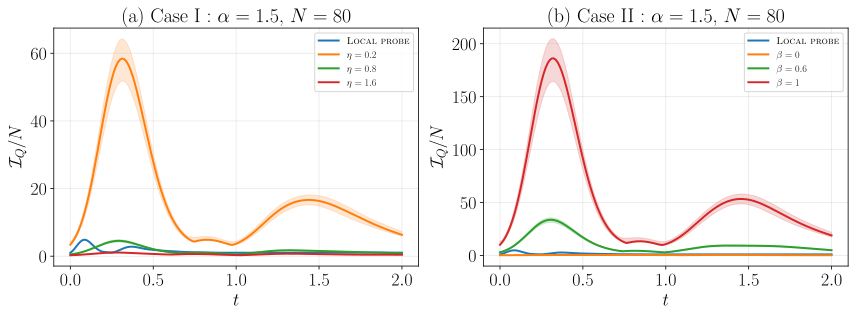

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# =========================
# Fig. 3(a): Case I, alpha > 1
# =========================
ax = axes[0]
alpha = alpha_gt1_case1
N = N_gt1

qfi_local = get_case1_local_curve(alpha, N)
idx_local, _ = best_from_curve(qfi_local, case1_t)

line_local, = ax.plot(case1_t, qfi_local / N, lw=2, label=r"\textsc{Local probe}")


for eta in etas_case1_gt1:
    qfi = get_case1_nonlocal_curve(alpha, eta, N)
    qfi_groups = get_case1_nonlocal_groups(alpha, eta, N)
    low, high = curve_ci(qfi_groups)

    idx, _ = best_from_curve(qfi, case1_t)
    line, = ax.plot(case1_t, qfi / N, lw=2, label=rf"$\eta={eta:g}$")
    ax.fill_between(case1_t, low / N, high / N, alpha=0.18, color=line.get_color())


ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/N$")
# ax.set_yscale("log")
ax.set_title(r"(a) Power-law : $\alpha=1.5$, $N=80$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

# =========================
# Fig. 3(b): Case II, alpha > 1
# =========================
ax = axes[1]
alpha = alpha_gt1_case2
N = N_gt1

qfi_local = get_case2_local_curve(alpha, N)
idx_local, _ = best_from_curve(qfi_local, case2_t)

line_local, = ax.plot(case2_t, qfi_local / N, lw=2, label=r"\textsc{Local probe}")


for beta in betas_case2_gt1:
    qfi, R0 = get_case2_truncated_curve(alpha, beta, N)
    qfi_groups, _ = get_case2_truncated_groups(alpha, beta, N)
    low, high = curve_ci(qfi_groups)

    idx, _ = best_from_curve(qfi, case2_t)
    line, = ax.plot(case2_t, qfi / N, lw=2, label=rf"$\beta={beta:g}$")
    ax.fill_between(case2_t, low / N, high / N, alpha=0.18, color=line.get_color())


ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/N$")
# ax.set_yscale("log")
ax.set_title(r"(b) Truncated : $\alpha=1.5$, $N=80$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("Figure/Fig3_alpha_gt_1_representative_bootstrap.pdf", bbox_inches="tight")
plt.show()

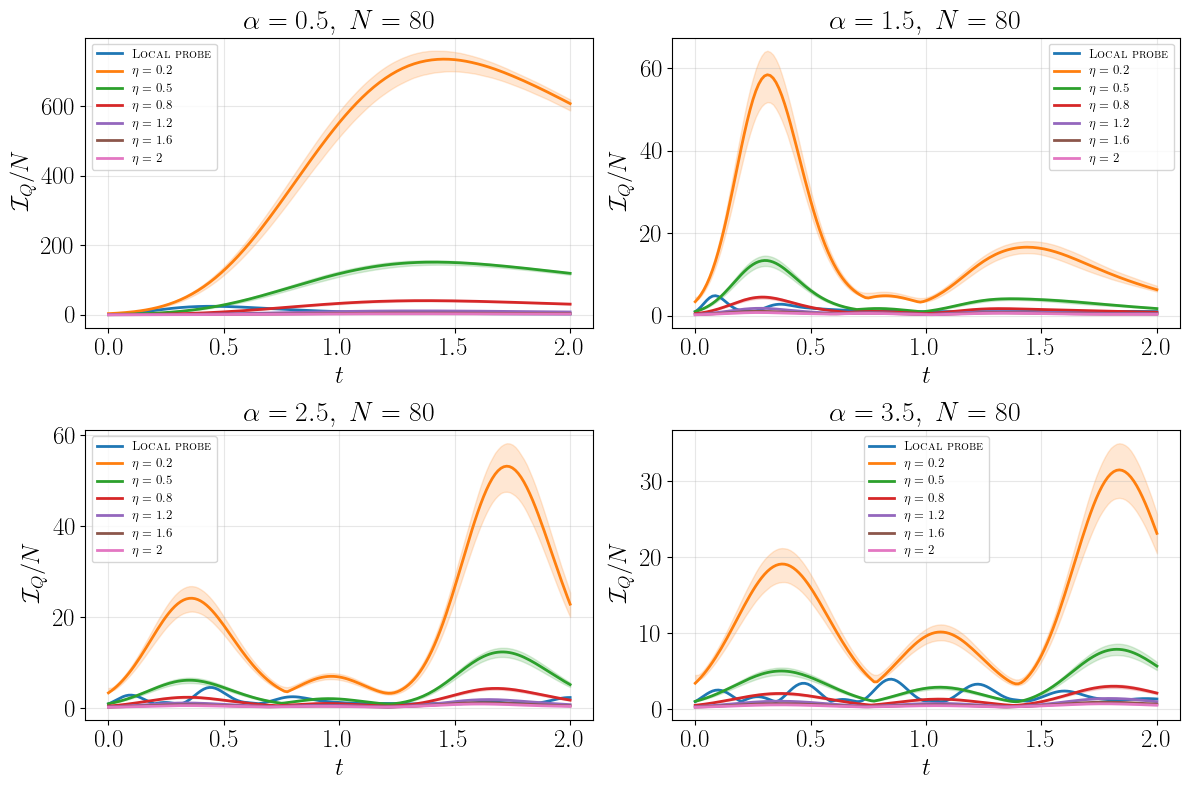

In [ ]:
# Dense scan for Case I with bootstrap CI
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ia, alpha in enumerate(case1_alphas):
    ax = axes[ia]
    N = 80

    qfi_local = get_case1_local_curve(alpha, N)
    ax.plot(case1_t, qfi_local / N, lw=2, label=r"\textsc{Local probe}")

    for eta in case1_etas:
        Ns_eta = available_N_case1_nonlocal(alpha, eta)
        if N not in Ns_eta:
            continue

        qfi = get_case1_nonlocal_curve(alpha, eta, N)
        qfi_groups = get_case1_nonlocal_groups(alpha, eta, N)

        low, high = curve_ci(qfi_groups)

        line, = ax.plot(case1_t, qfi / N, lw=2, label=rf"$\eta={eta:g}$")
        ax.fill_between(
            case1_t,
            low / N,
            high / N,
            alpha=0.18,
            color=line.get_color(),
        )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\mathcal{I}_Q/N$")
    ax.set_title(rf"$\alpha={alpha:g},\ N={N}$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("Figure/Case1_dense_scan_bootstrap.pdf", bbox_inches="tight")
plt.show()


===== DTWA vs Exact Benchmark =====

Case I (power-law):
t*_exact = 0.5500, t*_DTWA = 0.5250, rel.err = -4.55%
peak_exact = 19.5042, peak_DTWA = 22.6387, rel.err = 16.07%

Case II (truncated):
t*_exact = 0.5250, t*_DTWA = 0.5000, rel.err = -4.76%
peak_exact = 23.7288, peak_DTWA = 27.8247, rel.err = 17.26%


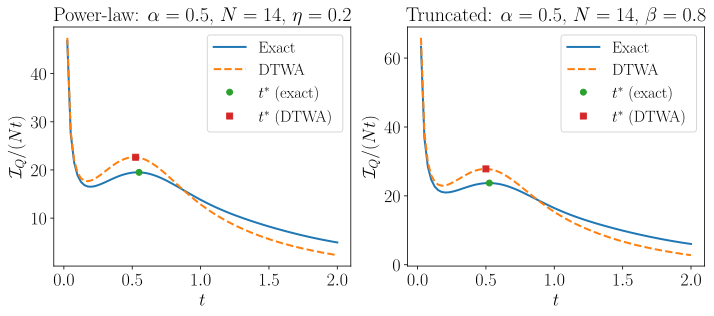

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# load benchmark data
# -----------------------------
bench = np.load("data/benchmark.npz", allow_pickle=True)

t_points = np.array(bench["t_points"], dtype=float)
results = bench["results"]

def to_dict_list(arr):
    out = []
    for x in arr:
        if hasattr(x, "item"):
            out.append(x.item())
        else:
            out.append(x)
    return out

results = to_dict_list(results)

# -----------------------------
# helpers
# -----------------------------
def find_entry(alpha, N, eta, beta):
    for item in results:
        if (
            abs(item["alpha"] - alpha) < 1e-12
            and item["N"] == N
            and abs(item["eta"] - eta) < 1e-12
            and abs(item["beta"] - beta) < 1e-12
        ):
            return item
    raise ValueError(
        f"No benchmark entry found for alpha={alpha}, N={N}, eta={eta}, beta={beta}"
    )

def qfi_over_nt(qfi, N, t_points):
    qfi = np.array(qfi, dtype=float)
    out = np.full_like(qfi, np.nan, dtype=float)
    mask = t_points > 0
    out[mask] = qfi[mask] / (N * t_points[mask])
    return out

def best_idx_over_nt(qfi, N, t_points, cut=1):
    arr = qfi_over_nt(qfi, N, t_points)
    idx = np.nanargmax(arr[cut:])
    return idx + cut

def extract_peak_info(qfi, N, t_points, idx):
    arr = qfi_over_nt(qfi, N, t_points)
    return t_points[idx], arr[idx]

def rel(a, b):
    return (a - b) / b

# -----------------------------
# choose benchmark point
# -----------------------------
alpha_target = 0.5
N_target = 14
eta_target = 0.2
beta_target = 0.8

entry = find_entry(alpha_target, N_target, eta_target, beta_target)

qfi_local = np.array(entry["qfi_local"], dtype=float)

qfi1_exact = np.array(entry["qfi_exact_powerlaw"], dtype=float)
qfi1_dtwa  = np.array(entry["qfi_dtwa_powerlaw"], dtype=float)

qfi2_exact = np.array(entry["qfi_exact_truncated"], dtype=float)
qfi2_dtwa  = np.array(entry["qfi_dtwa_truncated"], dtype=float)

R0 = int(entry["R0"])

# -----------------------------
# compute normalized curves
# -----------------------------
qfi1_exact_nt = qfi_over_nt(qfi1_exact, N_target, t_points)
qfi1_dtwa_nt  = qfi_over_nt(qfi1_dtwa,  N_target, t_points)

qfi2_exact_nt = qfi_over_nt(qfi2_exact, N_target, t_points)
qfi2_dtwa_nt  = qfi_over_nt(qfi2_dtwa,  N_target, t_points)

qfi_local_nt  = qfi_over_nt(qfi_local,  N_target, t_points)

# -----------------------------
# find optimal indices
# -----------------------------
idx1_exact = find_optimal_index_auto(qfi1_exact, t_points)
idx1_dtwa  = find_optimal_index_auto(qfi1_dtwa, t_points)

idx2_exact = find_optimal_index_auto(qfi2_exact, t_points)
idx2_dtwa  = find_optimal_index_auto(qfi2_dtwa, t_points)

# -----------------------------
# extract peak info
# -----------------------------
t1_exact, peak1_exact = extract_peak_info(qfi1_exact, N_target, t_points, idx1_exact)
t1_dtwa,  peak1_dtwa  = extract_peak_info(qfi1_dtwa,  N_target, t_points, idx1_dtwa)

t2_exact, peak2_exact = extract_peak_info(qfi2_exact, N_target, t_points, idx2_exact)
t2_dtwa,  peak2_dtwa  = extract_peak_info(qfi2_dtwa,  N_target, t_points, idx2_dtwa)

# -----------------------------
# print results (IMPORTANT)
# -----------------------------
print("\n===== DTWA vs Exact Benchmark =====")

print("\nCase I (power-law):")
print(f"t*_exact = {t1_exact:.4f}, t*_DTWA = {t1_dtwa:.4f}, rel.err = {rel(t1_dtwa, t1_exact):.2%}")
print(f"peak_exact = {peak1_exact:.4f}, peak_DTWA = {peak1_dtwa:.4f}, rel.err = {rel(peak1_dtwa, peak1_exact):.2%}")

print("\nCase II (truncated):")
print(f"t*_exact = {t2_exact:.4f}, t*_DTWA = {t2_dtwa:.4f}, rel.err = {rel(t2_dtwa, t2_exact):.2%}")
print(f"peak_exact = {peak2_exact:.4f}, peak_DTWA = {peak2_dtwa:.4f}, rel.err = {rel(peak2_dtwa, peak2_exact):.2%}")

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Case I
ax = axes[0]
ax.plot(t_points[1:], qfi1_exact_nt[1:], lw=2, label="Exact")
ax.plot(t_points[1:], qfi1_dtwa_nt[1:], lw=2, ls="--", label="DTWA")

ax.plot(t_points[idx1_exact], qfi1_exact_nt[idx1_exact], "o", ms=6, label=r"$t^*$ (exact)")
ax.plot(t_points[idx1_dtwa],  qfi1_dtwa_nt[idx1_dtwa],  "s", ms=6, label=r"$t^*$ (DTWA)")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/(N t)$")
ax.set_title(rf"Power-law: $\alpha={alpha_target}$, $N={N_target}$, $\eta={eta_target}$")
ax.legend()

# Case II
ax = axes[1]
ax.plot(t_points[1:], qfi2_exact_nt[1:], lw=2, label="Exact")
ax.plot(t_points[1:], qfi2_dtwa_nt[1:], lw=2, ls="--", label="DTWA")

ax.plot(t_points[idx2_exact], qfi2_exact_nt[idx2_exact], "o", ms=6, label=r"$t^*$ (exact)")
ax.plot(t_points[idx2_dtwa],  qfi2_dtwa_nt[idx2_dtwa],  "s", ms=6, label=r"$t^*$ (DTWA)")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/(N t)$")
ax.set_title(rf"Truncated: $\alpha={alpha_target}$, $N={N_target}$, $\beta={beta_target}$")
ax.legend()

plt.tight_layout()

# save
os.makedirs("fig", exist_ok=True)
plt.savefig("Figure/benchmark_exact_vs_dtwa_clean.pdf", bbox_inches="tight")

plt.show()

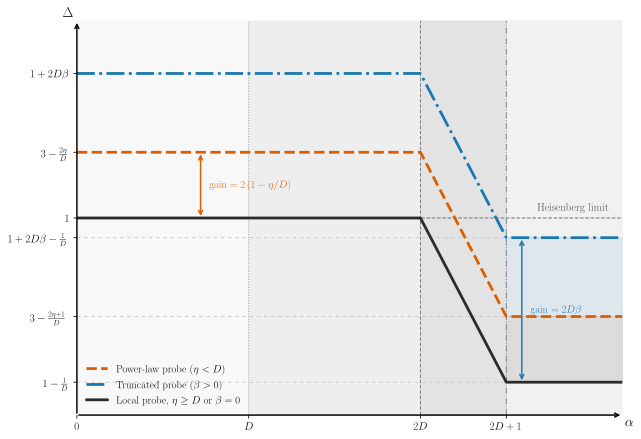

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Schematic strong-precision-limit figure for the main text
# Three curves only:
#   1) local probe  (= eta > D or beta = 0)
#   2) power-law nonlocal probe with eta < D
#   3) truncated probe with beta > 0
#
# The piecewise forms follow the summary formulas in your paper:
# local:      Δ <= 1 - 1/D              (alpha > 2D+1)
#             Δ <= 1 - ξ/D = 3 - alpha/D   (2D < alpha <= 2D+1)
#             Δ ~ 1                     (alpha <= 2D, asymptotically)
#
# power-law:  Δ <= 3 - (2η+1)/D        (alpha > 2D+1)
# eta < D     Δ <= 3 - 2η/D - ξ/D
#                   = 5 - alpha/D - 2η/D   (2D < alpha <= 2D+1)
#             Δ ~ 3 - 2η/D             (alpha <= 2D, schematic plateau)
#
# truncated:  Δ <= 1 + 2Dβ - 1/D       (alpha > 2D+1)
# beta > 0    Δ <= 1 + 2Dβ - ξ/D
#                   = 3 + 2Dβ - alpha/D   (2D < alpha <= 2D+1)
#             Δ ~ 1 + 2Dβ              (alpha <= 2D, schematic plateau)
# =========================================================
# -------------------------
# Parameters used only to shape the schematic curves
# (not displayed in the figure)
# -------------------------
D = 2
eta_ratio = 0.90
beta = 0.11
eta = eta_ratio * D

alpha_max = 2 * D + 2.35
alpha = np.linspace(0, alpha_max, 1400)

# -------------------------
# Piecewise schematic bounds
# -------------------------
def delta_local(alpha, D):
    out = np.zeros_like(alpha, dtype=float)

    m1 = alpha <= 2 * D
    out[m1] = 1.0

    m2 = (alpha > 2 * D) & (alpha <= 2 * D + 1)
    out[m2] = 3.0 - alpha[m2] / D

    m3 = alpha > 2 * D + 1
    out[m3] = 1.0 - 1.0 / D
    return out


def delta_eta(alpha, D, eta):
    out = np.zeros_like(alpha, dtype=float)

    m1 = alpha <= 2 * D
    out[m1] = 3.0 - 2.0 * eta / D

    m2 = (alpha > 2 * D) & (alpha <= 2 * D + 1)
    out[m2] = 5.0 - alpha[m2] / D - 2.0 * eta / D

    m3 = alpha > 2 * D + 1
    out[m3] = 3.0 - (2.0 * eta + 1.0) / D
    return out


def delta_beta(alpha, D, beta):
    out = np.zeros_like(alpha, dtype=float)

    m1 = alpha <= 2 * D
    out[m1] = 1.0 + 2.0 * D * beta

    m2 = (alpha > 2 * D) & (alpha <= 2 * D + 1)
    out[m2] = 3.0 + 2.0 * D * beta - alpha[m2] / D

    m3 = alpha > 2 * D + 1
    out[m3] = 1.0 + 2.0 * D * beta - 1.0 / D
    return out


y_local = delta_local(alpha, D)
y_eta   = delta_eta(alpha, D, eta)
y_beta  = delta_beta(alpha, D, beta)

# key levels
local_max = 1.0
local_min = 1.0 - 1.0 / D

eta_max = 3.0 - 2.0 * eta / D
eta_min = 3.0 - (2.0 * eta + 1.0) / D

beta_max = 1.0 + 2.0 * D * beta
beta_min = 1.0 + 2.0 * D * beta - 1.0 / D

# -------------------------
# Colors
# -------------------------
c_local = '#2b2b2b'
c_eta   = '#d95f02'
c_beta  = '#1b78b3'

shade1 = '#f8f8f8'
shade2 = '#eeeeee'
shade3 = '#e3e3e3'
shade4 = '#f1f1f1'

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(9.0, 6.2))

# background alpha sectors
ax.axvspan(0, D,               color=shade1, zorder=0)
ax.axvspan(D, 2*D,             color=shade2, zorder=0)
ax.axvspan(2*D, 2*D + 1,       color=shade3, zorder=0)
ax.axvspan(2*D + 1, alpha_max, color=shade4, zorder=0)

# sector boundaries
ax.axvline(D,       color='0.65', lw=1.0, ls=':')
ax.axvline(2*D,     color='0.50', lw=1.0, ls='--')
ax.axvline(2*D + 1, color='0.50', lw=1.0, ls='-.')

# Heisenberg limit
ax.axhline(1.0, color='0.45', lw=1.0, ls='--')
ax.text(alpha_max - 0.08, 1.0 + 0.016, 'Heisenberg limit',
        ha='right', va='bottom', fontsize=11, color='0.30')

# subtle fills between curves in short-range regime
mask_sr = alpha >= (2 * D + 1)
ax.fill_between(alpha[mask_sr], y_local[mask_sr], y_eta[mask_sr],
                color=c_eta, alpha=0.08, zorder=1)
ax.fill_between(alpha[mask_sr], y_local[mask_sr], y_beta[mask_sr],
                color=c_beta, alpha=0.08, zorder=1)

# main curves
ax.plot(alpha, y_eta, color=c_eta, lw=2.8, ls='--', solid_capstyle='round',
        label=r'Power-law probe $(\eta < D)$')
ax.plot(alpha, y_beta, color=c_beta, lw=2.8, ls='-.', solid_capstyle='round',
        label=r'Truncated probe $(\beta > 0)$')
ax.plot(alpha, y_local, color=c_local, lw=2.8, solid_capstyle='round',
        label=r'Local probe, $\eta \geq D$ or $\beta=0$')

# guide lines
guide_kw = dict(color='0.78', lw=0.9, ls=(0, (4, 4)), zorder=0)
ax.hlines(local_min, xmin=0, xmax=alpha_max - 0.10, **guide_kw)
ax.hlines(local_max, xmin=0, xmax=0.55, **guide_kw)
ax.hlines(eta_max,   xmin=0, xmax=0.95, **guide_kw)
ax.hlines(eta_min,   xmin=0, xmax=alpha_max - 0.10, **guide_kw)
ax.hlines(beta_max,  xmin=0, xmax=1.20, **guide_kw)
ax.hlines(beta_min,  xmin=0, xmax=alpha_max - 0.10, **guide_kw)

# ticks
yticks = sorted(set([local_min, local_max, eta_min, eta_max, beta_min, beta_max]))
ax.set_yticks(yticks)
ax.set_yticklabels([
    r'$1-\frac{1}{D}$' if np.isclose(y, local_min) else
    r'$1$' if np.isclose(y, local_max) else
    r'$3-\frac{2\eta+1}{D}$' if np.isclose(y, eta_min) else
    r'$3-\frac{2\eta}{D}$' if np.isclose(y, eta_max) else
    r'$1+2D\beta-\frac{1}{D}$' if np.isclose(y, beta_min) else
    r'$1+2D\beta$' if np.isclose(y, beta_max) else
    ''
    for y in yticks
], fontsize=11)

ax.set_xticks([0, D, 2*D, 2*D + 1])
ax.set_xticklabels([r'$0$', r'$D$', r'$2D$', r'$2D+1$'], fontsize=11)

# gain arrows
x_eta_gain = 0.72 * D
ax.annotate(
    '', xy=(x_eta_gain, eta_max), xytext=(x_eta_gain, local_max),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color=c_eta)
)
ax.text(
    x_eta_gain + 0.10,
    0.5 * (eta_max + local_max),
    r'gain $=2\left(1-\eta/D\right)$',
    color=c_eta, fontsize=10.5, ha='left', va='center'
)

x_beta_gain = 2 * D + 1.18
ax.annotate(
    '', xy=(x_beta_gain, beta_min), xytext=(x_beta_gain, local_min),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color=c_beta)
)
ax.text(
    x_beta_gain + 0.10,
    0.5 * (beta_min + local_min),
    r'gain $=2D\beta$',
    color=c_beta, fontsize=10.5, ha='left', va='center'
)

# axes formatting
ax.set_xlim(0, alpha_max)
ax.set_ylim(min(local_min, eta_min) - 0.10, max(eta_max, beta_max) + 0.16)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# arrowed axes
ax.annotate(
    '', xy=(xmax, ymin), xytext=(xmin, ymin),
    arrowprops=dict(arrowstyle='->', lw=1.45, color='black'),
    clip_on=False
)
ax.annotate(
    '', xy=(xmin, ymax), xytext=(xmin, ymin),
    arrowprops=dict(arrowstyle='->', lw=1.45, color='black'),
    clip_on=False
)

# axis symbols only
ax.text(xmax + 0.03, ymin - 0.004, r'$\alpha$', fontsize=14, ha='left', va='top')
ax.text(xmin - 0.035, ymax + 0.004, r'$\Delta$', fontsize=14, ha='right', va='bottom')

# legend
ax.legend(frameon=False, fontsize=10.6, loc='lower left')

plt.tight_layout()
plt.savefig("Figure/Schematic_Delta_vs_alpha.pdf", bbox_inches="tight")
plt.show()

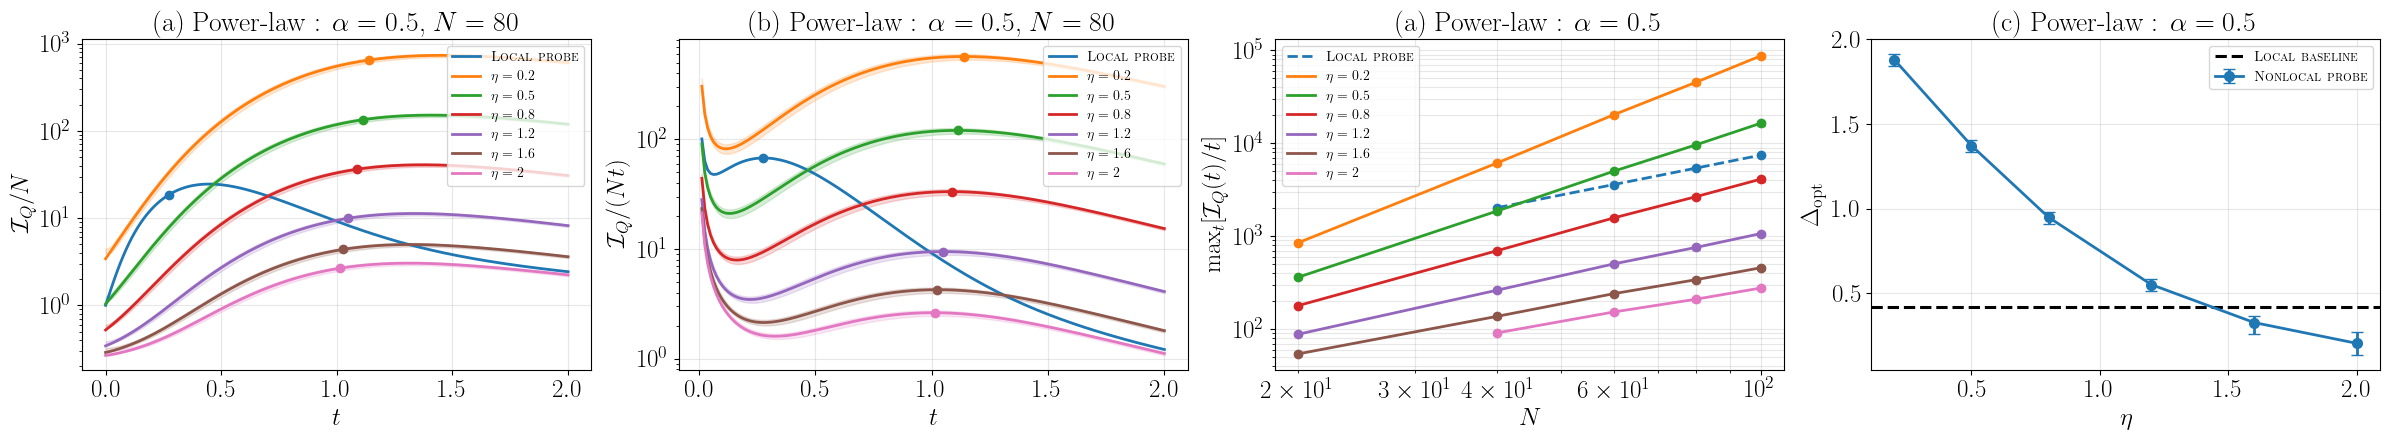

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 4.5))

# =========================
# 左 Panel: I_Q / N vs t (原 Fig 1 左)
# =========================
ax = axes[0]
alpha = alpha_case1_main
N = N_case1_main

# local baseline
qfi_local = get_case1_local_curve(alpha, N)
idx_local, _ = best_from_curve(qfi_local, case1_t)

line_local, = ax.plot(case1_t, qfi_local / N, lw=2, label=r"\textsc{Local probe}")
if idx_local is not None:
    ax.plot(case1_t[idx_local], qfi_local[idx_local] / N, "o", ms=6, color=line_local.get_color())

# nonlocal curves + CI
for eta in etas_case1_time:
    qfi = get_case1_nonlocal_curve(alpha, eta, N)
    qfi_groups = get_case1_nonlocal_groups(alpha, eta, N)
    low, high = curve_ci(qfi_groups)

    idx, _ = best_from_curve(qfi, case1_t)
    line, = ax.plot(case1_t, qfi / N, lw=2, label=rf"$\eta={eta:g}$")
    ax.fill_between(case1_t, low / N, high / N, alpha=0.18, color=line.get_color())
    if idx is not None:
        ax.plot(case1_t[idx], qfi[idx] / N, "o", ms=6, color=line.get_color())

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/N$")
ax.set_yscale("log")
ax.set_title(r"(a) Power-law : $\alpha=0.5$, $N=80$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc=1)

# =========================
# 中 Panel: I_Q / (Nt) vs t (原 AppFig A 左)
# =========================
ax = axes[1]
alpha = alpha_case1_main
N = N_case1_main

qfi_local = get_case1_local_curve(alpha, N)
idx_local, _ = best_from_curve(qfi_local, case1_t)

qfi_local_over_nt = np.full_like(qfi_local, np.nan)
qfi_local_over_nt[1:] = qfi_local[1:] / (N * case1_t[1:])

line_local, = ax.plot(case1_t, qfi_local_over_nt, lw=2, label=r"\textsc{Local probe}")
if idx_local is not None:
    ax.plot(case1_t[idx_local], qfi_local[idx_local] / (N * case1_t[idx_local]), "o", ms=6, color=line_local.get_color())

for eta in etas_case1_time:
    qfi = get_case1_nonlocal_curve(alpha, eta, N)
    qfi_groups = get_case1_nonlocal_groups(alpha, eta, N)
    low, high = curve_ci(qfi_groups)

    idx, _ = best_from_curve(qfi, case1_t)

    qfi_over_nt = np.full_like(qfi, np.nan)
    qfi_over_nt[1:] = qfi[1:] / (N * case1_t[1:])

    low_over_nt = np.full_like(low, np.nan)
    high_over_nt = np.full_like(high, np.nan)
    low_over_nt[1:] = low[1:] / (N * case1_t[1:])
    high_over_nt[1:] = high[1:] / (N * case1_t[1:])

    line, = ax.plot(case1_t, qfi_over_nt, lw=2, label=rf"$\eta={eta:g}$")
    ax.fill_between(case1_t, low_over_nt, high_over_nt, alpha=0.18, color=line.get_color())
    if idx is not None:
        ax.plot(case1_t[idx], qfi[idx] / (N * case1_t[idx]), "o", ms=6, color=line.get_color())

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/(N t)$")
ax.set_yscale("log")
ax.set_title(r"(b) Power-law : $\alpha=0.5$, $N=80$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc="upper right")

# =========================
# 3 Panel: extract Delta
# =========================

ax=axes[2]
alpha = alpha_case1_main

# local probe
Ns_local = available_N_case1_local(alpha)
best_vals_local = []
for N in Ns_local:
    qfi_local = get_case1_local_curve(alpha, N)
    _, best = best_from_curve(qfi_local, case1_t)
    best_vals_local.append(best)

line_local, = ax.plot(Ns_local, best_vals_local, "--", lw=2, label=r"\textsc{Local probe}")
ax.plot(Ns_local, best_vals_local, "o", ms=6, color=line_local.get_color())

# nonlocal probes with CI
for eta in etas_case1_delta:
    Ns_eta = available_N_case1_nonlocal(alpha, eta)
    best_vals = []
    low_err = []
    high_err = []
    Ns_used = []

    for N in Ns_eta:
        qfi = get_case1_nonlocal_curve(alpha, eta, N)
        qfi_groups = get_case1_nonlocal_groups(alpha, eta, N)

        _, best_full = best_from_curve(qfi, case1_t)
        _, low, high = best_ci(qfi_groups, case1_t)

        if np.isfinite(best_full):
            Ns_used.append(N)
            best_vals.append(best_full)
            low_err.append(best_full - low if np.isfinite(low) else np.nan)
            high_err.append(high - best_full if np.isfinite(high) else np.nan)

    if len(Ns_used) == 0:
        continue

    line, = ax.plot(Ns_used, best_vals, "-", lw=2, label=rf"$\eta={eta:g}$")
    low_arr = np.array(low_err, dtype=float)
    high_arr = np.array(high_err, dtype=float)
    mask = np.isfinite(low_arr) & np.isfinite(high_arr)
    ax.errorbar(
        np.array(Ns_used)[mask],
        np.array(best_vals)[mask],
        yerr=[low_arr[mask], high_arr[mask]],
        fmt="o",
        ms=6,
        capsize=3,
        color=line.get_color(),
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\max_t[\mathcal{I}_Q(t)/t]$")
ax.set_title(r"(c) Power-law : $\alpha=0.5$")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=10)


# =========================
# 右 Panel: Delta vs eta (原 Fig 1 右)
# =========================
ax = axes[3]
alpha = alpha_case1_main

# local baseline
Ns_local = available_N_case1_local(alpha)
local_best = []
for N in Ns_local:
    qfi_local = get_case1_local_curve(alpha, N)
    _, best = best_from_curve(qfi_local, case1_t)
    local_best.append(best)
delta_local, _, _ = fit_delta_from_best_values(Ns_local, local_best)

# nonlocal with bootstrap CI
eta_list = []
delta_list = []
delta_low = []
delta_high = []

for eta in etas_case1_delta:
    delta, low, high = delta_ci_case1(alpha, eta)
    eta_list.append(eta)
    delta_list.append(delta)
    delta_low.append(low)
    delta_high.append(high)

eta_arr = np.array(eta_list, dtype=float)
delta_arr = np.array(delta_list, dtype=float)
delta_low = np.array(delta_low, dtype=float)
delta_high = np.array(delta_high, dtype=float)

mask = np.isfinite(delta_arr)
ax.errorbar(
    eta_arr[mask],
    delta_arr[mask],
    yerr=[delta_arr[mask] - delta_low[mask], delta_high[mask] - delta_arr[mask]],
    fmt="o-",
    lw=2,
    ms=7,
    capsize=4,
    label=r"\textsc{Nonlocal probe}",
)

if np.isfinite(delta_local):
    ax.axhline(delta_local, ls="--", color="k", label=r"\textsc{Local baseline}")

ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\Delta_{\mathrm{opt}}$")
ax.set_title(r"(d) Power-law : $\alpha=0.5$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("Figure/powerlaw_alphaless1.pdf", bbox_inches="tight")
plt.show()

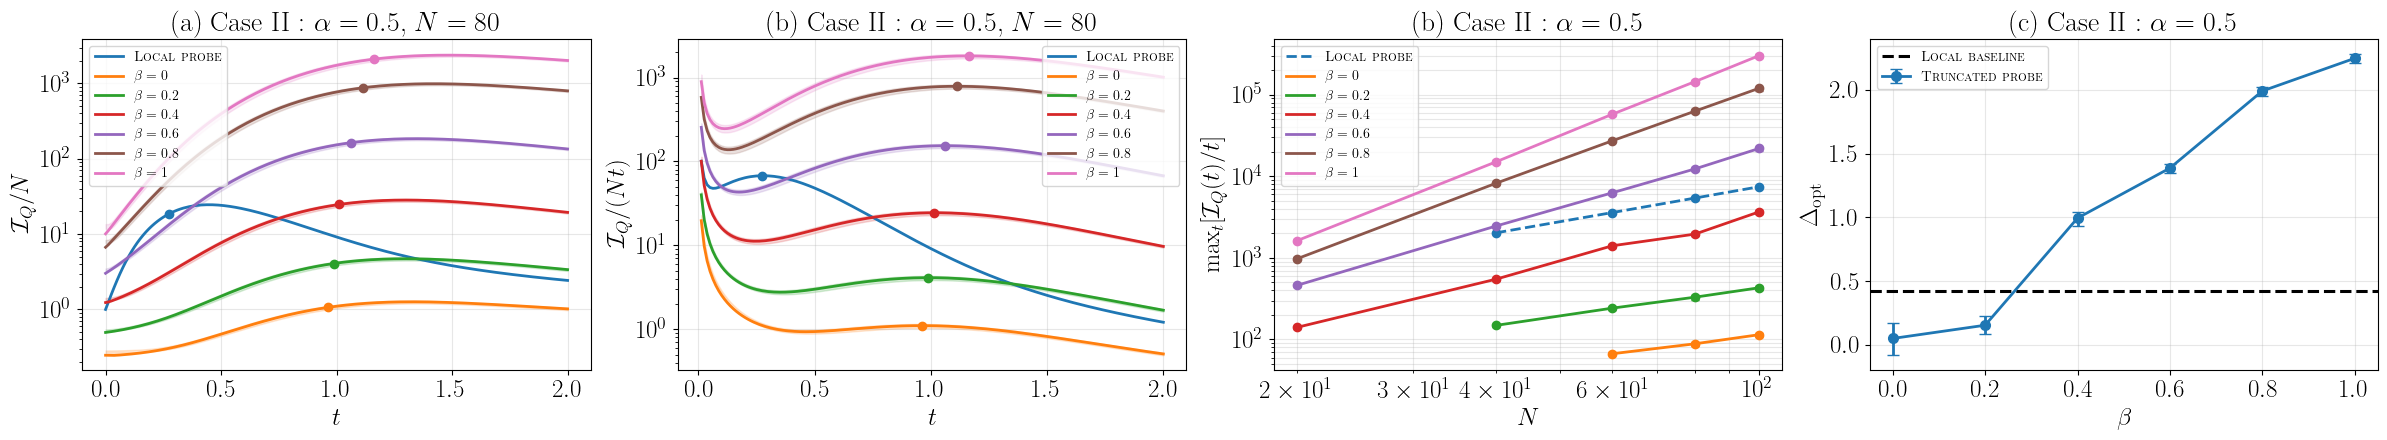

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 4.5))

# =========================
# 左 Panel: I_Q / N vs t (原 Fig 2 左)
# =========================
ax = axes[0]
alpha = alpha_case2_main
N = N_case2_main

# local baseline
qfi_local = get_case2_local_curve(alpha, N)
idx_local, _ = best_from_curve(qfi_local, case2_t)

line_local, = ax.plot(case2_t, qfi_local / N, lw=2, label=r"\textsc{Local probe}")
if idx_local is not None:
    ax.plot(case2_t[idx_local], qfi_local[idx_local] / N, "o", ms=6, color=line_local.get_color())

# truncated curves + CI
for beta in betas_case2_time:
    qfi, R0 = get_case2_truncated_curve(alpha, beta, N)
    qfi_groups, _ = get_case2_truncated_groups(alpha, beta, N)
    low, high = curve_ci(qfi_groups)

    idx, _ = best_from_curve(qfi, case2_t)
    line, = ax.plot(case2_t, qfi / N, lw=2, label=rf"$\beta={beta:g}$")
    ax.fill_between(case2_t, low / N, high / N, alpha=0.18, color=line.get_color())
    if idx is not None:
        ax.plot(case2_t[idx], qfi[idx] / N, "o", ms=6, color=line.get_color())

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/N$")
ax.set_yscale("log")
ax.set_title(r"(a) Truncated : $\alpha=0.5$, $N=80$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

# =========================
# 中 Panel: I_Q / (Nt) vs t (原 AppFig A 右)
# =========================
ax = axes[1]
alpha = alpha_case2_main
N = N_case2_main

qfi_local = get_case2_local_curve(alpha, N)
idx_local, _ = best_from_curve(qfi_local, case2_t)

qfi_local_over_nt = np.full_like(qfi_local, np.nan)
qfi_local_over_nt[1:] = qfi_local[1:] / (N * case2_t[1:])

line_local, = ax.plot(case2_t, qfi_local_over_nt, lw=2, label=r"\textsc{Local probe}")
if idx_local is not None:
    ax.plot(case2_t[idx_local], qfi_local[idx_local] / (N * case2_t[idx_local]), "o", ms=6, color=line_local.get_color())

for beta in betas_case2_time:
    qfi, R0 = get_case2_truncated_curve(alpha, beta, N)
    qfi_groups, _ = get_case2_truncated_groups(alpha, beta, N)
    low, high = curve_ci(qfi_groups)

    idx, _ = best_from_curve(qfi, case2_t)

    qfi_over_nt = np.full_like(qfi, np.nan)
    qfi_over_nt[1:] = qfi[1:] / (N * case2_t[1:])

    low_over_nt = np.full_like(low, np.nan)
    high_over_nt = np.full_like(high, np.nan)
    low_over_nt[1:] = low[1:] / (N * case2_t[1:])
    high_over_nt[1:] = high[1:] / (N * case2_t[1:])

    line, = ax.plot(case2_t, qfi_over_nt, lw=2, label=rf"$\beta={beta:g}$")
    ax.fill_between(case2_t, low_over_nt, high_over_nt, alpha=0.18, color=line.get_color())
    if idx is not None:
        ax.plot(case2_t[idx], qfi[idx] / (N * case2_t[idx]), "o", ms=6, color=line.get_color())

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\mathcal{I}_Q/(N t)$")
ax.set_yscale("log")
ax.set_title(r"(b) Truncated : $\alpha=0.5$, $N=80$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc="upper right")



ax=axes[2]
alpha = alpha_case2_main

# local probe
Ns_local = available_N_case2_local(alpha)
best_vals_local = []
for N in Ns_local:
    qfi_local = get_case2_local_curve(alpha, N)
    _, best = best_from_curve(qfi_local, case2_t)
    best_vals_local.append(best)

line_local, = ax.plot(Ns_local, best_vals_local, "--", lw=2, label=r"\textsc{Local probe}")
ax.plot(Ns_local, best_vals_local, "o", ms=6, color=line_local.get_color())

# truncated probes with CI
for beta in betas_case2_delta:
    Ns_beta = available_N_case2_truncated(alpha, beta)
    best_vals = []
    low_err = []
    high_err = []
    Ns_used = []

    for N in Ns_beta:
        qfi, _ = get_case2_truncated_curve(alpha, beta, N)
        qfi_groups, _ = get_case2_truncated_groups(alpha, beta, N)

        _, best_full = best_from_curve(qfi, case2_t)
        _, low, high = best_ci(qfi_groups, case2_t)

        if np.isfinite(best_full):
            Ns_used.append(N)
            best_vals.append(best_full)
            low_err.append(best_full - low if np.isfinite(low) else np.nan)
            high_err.append(high - best_full if np.isfinite(high) else np.nan)

    if len(Ns_used) == 0:
        continue

    line, = ax.plot(Ns_used, best_vals, "-", lw=2, label=rf"$\beta={beta:g}$")
    low_arr = np.array(low_err, dtype=float)
    high_arr = np.array(high_err, dtype=float)
    mask = np.isfinite(low_arr) & np.isfinite(high_arr)
    ax.errorbar(
        np.array(Ns_used)[mask],
        np.array(best_vals)[mask],
        yerr=[low_arr[mask], high_arr[mask]],
        fmt="o",
        ms=6,
        capsize=3,
        color=line.get_color(),
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\max_t[\mathcal{I}_Q(t)/t]$")
ax.set_title(r"(c) Truncated : $\alpha=0.5$")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=10)


# =========================
# 右 Panel: Delta vs beta (原 Fig 2 右)
# =========================
ax = axes[3]
alpha = alpha_case2_main

# local baseline
Ns_local = available_N_case2_local(alpha)
local_best = []
for N in Ns_local:
    qfi_local = get_case2_local_curve(alpha, N)
    _, best = best_from_curve(qfi_local, case2_t)
    local_best.append(best)
delta_local, _, _ = fit_delta_from_best_values(Ns_local, local_best)

# truncated with bootstrap CI
beta_list = []
delta_list = []
delta_low = []
delta_high = []

for beta in betas_case2_delta:
    delta, low, high = delta_ci_case2(alpha, beta)
    beta_list.append(beta)
    delta_list.append(delta)
    delta_low.append(low)
    delta_high.append(high)

beta_arr = np.array(beta_list, dtype=float)
delta_arr = np.array(delta_list, dtype=float)
delta_low = np.array(delta_low, dtype=float)
delta_high = np.array(delta_high, dtype=float)

mask = np.isfinite(delta_arr)
ax.errorbar(
    beta_arr[mask],
    delta_arr[mask],
    yerr=[delta_arr[mask] - delta_low[mask], delta_high[mask] - delta_arr[mask]],
    fmt="o-",
    lw=2,
    ms=7,
    capsize=4,
    label=r"\textsc{Truncated probe}",
)

if np.isfinite(delta_local):
    ax.axhline(delta_local, ls="--", color="k", label=r"\textsc{Local baseline}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\Delta_{\mathrm{opt}}$")
ax.set_title(r"(d) Truncated : $\alpha=0.5$")
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("Figure/truncated_alphaless1.pdf", bbox_inches="tight")
plt.show()